### Description
The Tanzanian tourism sector plays a significant role in the Tanzanian economy, contributing about 17% to the country’s GDP and 25% of all foreign exchange revenues. The sector, which provides direct employment for more than 600,000 people and up to 2 million people indirectly, generated approximately $2.4 billion in 2018 according to government statistics. Tanzania received a record 1.1 million international visitor arrivals in 2014, mostly from Europe, the US and Africa.

Tanzania is the only country in the world which has allocated more than 25% of its total area for wildlife, national parks, and protected areas.There are 16 national parks in Tanzania, 28 game reserves, 44 game-controlled areas, two marine parks and one conservation area.

Tanzania’s tourist attractions include the Serengeti plains, which hosts the largest terrestrial mammal migration in the world; the Ngorongoro Crater, the world’s largest intact volcanic caldera and home to the highest density of big game in Africa; Kilimanjaro, Africa’s highest mountain; and the Mafia Island marine park; among many others. The scenery, topography, rich culture and very friendly people provide for excellent cultural tourism, beach holidays, honeymooning, game hunting, historical and archaeological ventures – and certainly the best wildlife photography safaris in the world.

The objective of this hackathon is to develop a machine learning model to predict what a tourist will spend when visiting Tanzania.The model can be used by different tour operators and the Tanzania Tourism Board to automatically help tourists across the world estimate their expenditure before visiting Tanzania.

### Objective
Predict tourist expenditure to optimize Tanzanian tourism marketing.

### Primary KPI
Mean Absolute Error (MAE)

### Caution
In this dataset you will see that tourists spend millions. Thats because of the different currencies. One million TZS is currently worth about 340 to 350 euros (depending on the exchange rate).

---

#### Setup / Import of libraries, models and visualization

In [4]:
# Import necessary libraries and models

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from IPython.display import display

# Formatting for presentation
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 50

In [5]:
datapath = "../data"

#### Load Data and get an overview

In [6]:
# 1. Get Data
train = pd.read_csv("data/Train.csv")
test = pd.read_csv("data/Test.csv")
meta = pd.read_csv("data/VariableDefinitions.csv")

#print(f"Train shape: {train.shape}")
train.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,No,No,No,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,No,Yes,Yes,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,No,No,No,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            3695 non-null   object 
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

In [8]:
train.describe()

,total_female,total_male,night_mainland,night_zanzibar,total_cost
count,4806.000000,4804.000000,4809.000000,4809.000000,4.809000e+03
mean,0.926758,1.009575,8.488043,2.304429,8.114389e+06
std,1.288242,1.138865,10.427624,4.227080,1.222490e+07
min,0.000000,0.000000,0.000000,0.000000,4.900000e+04
25%,0.000000,1.000000,3.000000,0.000000,8.121750e+05
50%,1.000000,1.000000,6.000000,0.000000,3.397875e+06
75%,1.000000,1.000000,11.000000,4.000000,9.945000e+06
max,49.000000,44.000000,145.000000,61.000000,9.953288e+07


Observation: We have a lot of columns with objective that we have to transform later in the process

#### EDA: Initial EDA (Target Analysis)

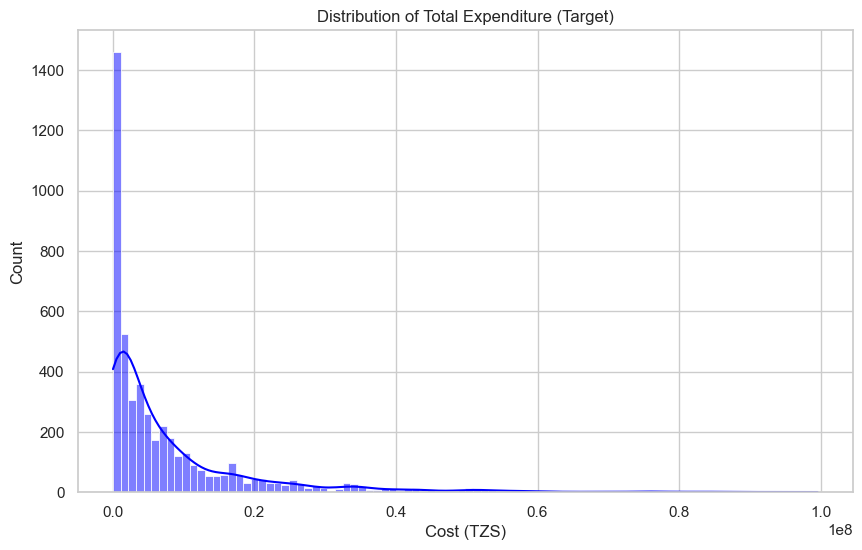

In [9]:
# 2. EDA - Checking the Target Variable
plt.figure(figsize=(10, 6))
sns.histplot(train['total_cost'], kde=True, color='blue')
plt.title('Distribution of Total Expenditure (Target)')
plt.xlabel('Cost (TZS)')
plt.show()

# Insight: If the plot is heavily right-skewed, 
# we might need np.log1p(train['total_cost']) later.

EDA Observation 1:
spending is usually very skewed (some people spend millions, many spend very little)

In [10]:
# Finding missing values and duplicates

train.isna().sum()

ID                          0
country                     0
age_group                   0
travel_with              1114
total_female                3
total_male                  5
purpose                     0
main_activity               0
info_source                 0
tour_arrangement            0
package_transport_int       0
package_accomodation        0
package_food                0
package_transport_tz        0
package_sightseeing         0
package_guided_tour         0
package_insurance           0
night_mainland              0
night_zanzibar              0
payment_mode                0
first_trip_tz               0
most_impressing           313
total_cost                  0
dtype: int64

In [11]:
train.duplicated().sum()

0

#### EDA: Missing value investigation

Columns with missing values:
travel_with        1114
most_impressing     313
total_male            5
total_female          3
dtype: int64


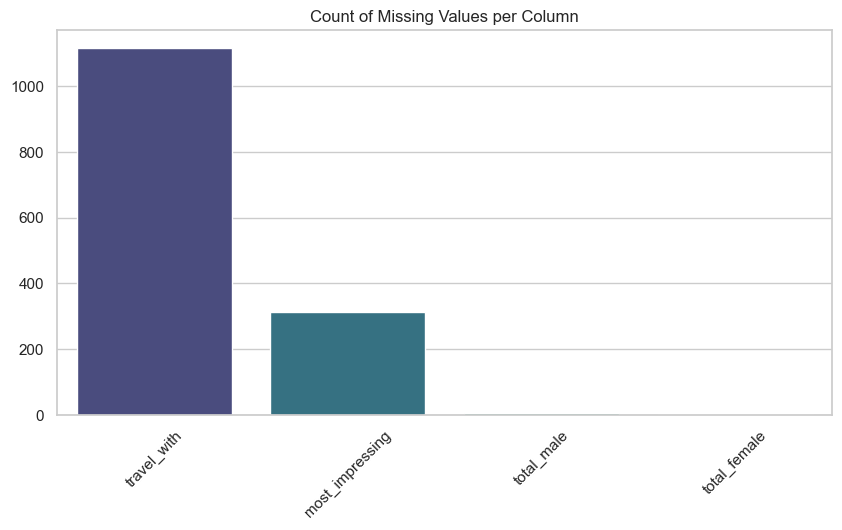

In [12]:
# Investigate missing values
missing_data = train.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_data)

# Visualize missingness
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_data.index, y=missing_data.values, palette="viridis")
plt.title("Count of Missing Values per Column")
plt.xticks(rotation=45)
plt.show()

##### EDA: Target Variable & Outliers

count    4.809000e+03
mean     8.114389e+06
std      1.222490e+07
min      4.900000e+04
25%      8.121750e+05
50%      3.397875e+06
75%      9.945000e+06
max      9.953288e+07
Name: total_cost, dtype: float64


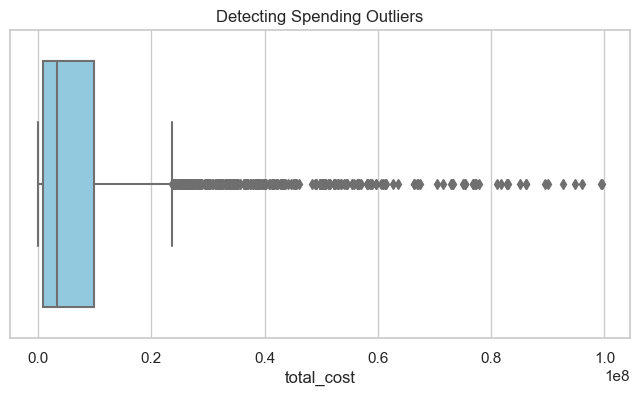

In [13]:
# Descriptive stats for the money
print(train['total_cost'].describe())

# Boxplot to see the "Whales" (Outliers)
plt.figure(figsize=(8, 4))
sns.boxplot(x=train['total_cost'], color='skyblue')
plt.title("Detecting Spending Outliers")
plt.show()

# Insight: If mean is much higher than median (50%), we have high-spending outliers.

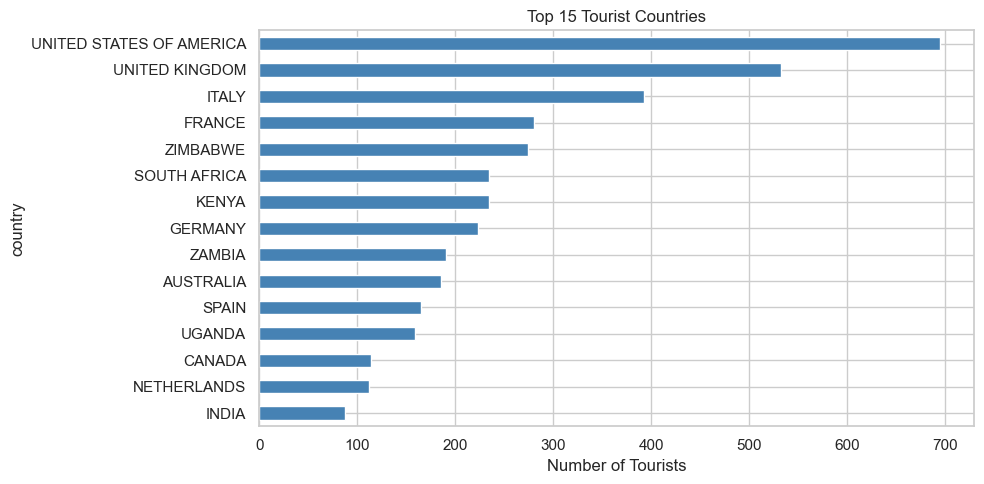

In [16]:
# ── 2.3 Top tourist countries ────────────────────────────────────────────────
top_countries = train['country'].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_countries.plot(kind='barh', color='steelblue')
plt.title('Top 15 Tourist Countries')
plt.xlabel('Number of Tourists')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

EDA Observation 2: We can see a huge gap between median (3.3mio) and mean (8.1mio). That means that we have a couple of "whales"/super rich people who spend a huge amount of money.


To put this into perspective: The median value of the dataset (3.3 million TZS) is approximately 1,150 euros, while the maximum value of 99 million TZS is equivalent to about 34,000 euros.

#### EDA: Relationship Analysis

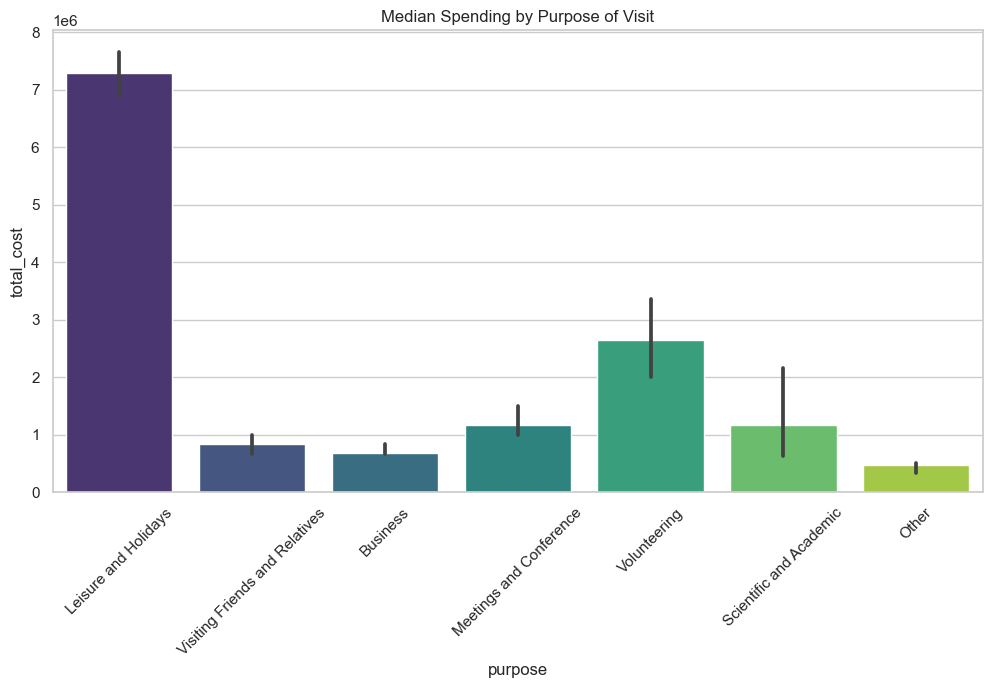

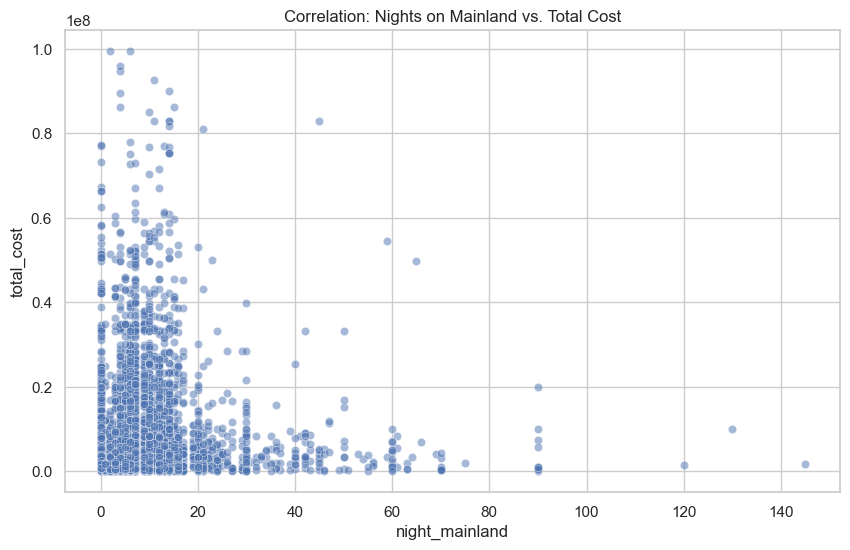

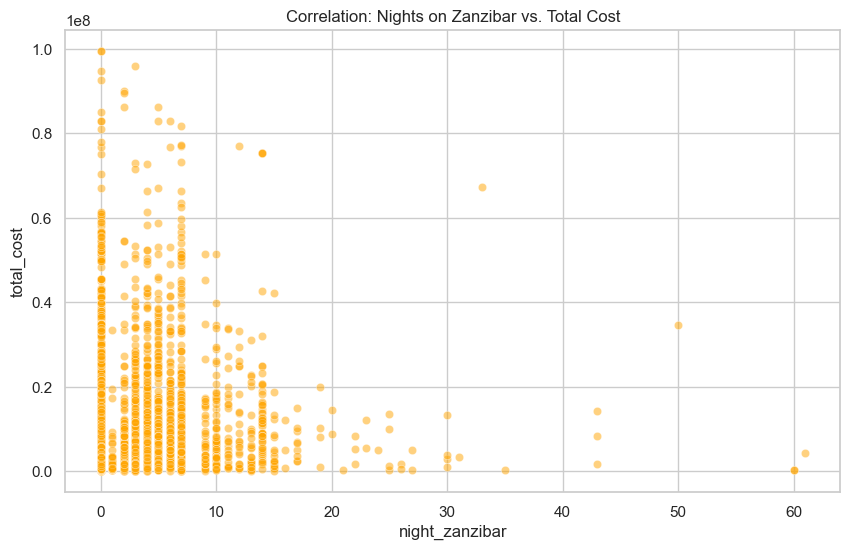

In [21]:
# Feature vs. Target (Business Insights)

# 1. Relationship: Purpose of Visit vs. Cost
plt.figure(figsize=(12, 6))
sns.barplot(data=train, x='purpose', y='total_cost', estimator=np.median, palette='viridis')
plt.xticks(rotation=45)
plt.title("Median Spending by Purpose of Visit")
plt.show()



# 2. Relationship: Nights on Mainland vs. Cost (Scatter plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='night_mainland', y='total_cost', alpha=0.5)
plt.title("Correlation: Nights on Mainland vs. Total Cost")
plt.show()

# 3. Relationship: Nights on Zanzibar vs. Cost (Scatter plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='night_zanzibar', y='total_cost', alpha=0.5, color='orange')
plt.title("Correlation: Nights on Zanzibar vs. Total Cost")
plt.show()

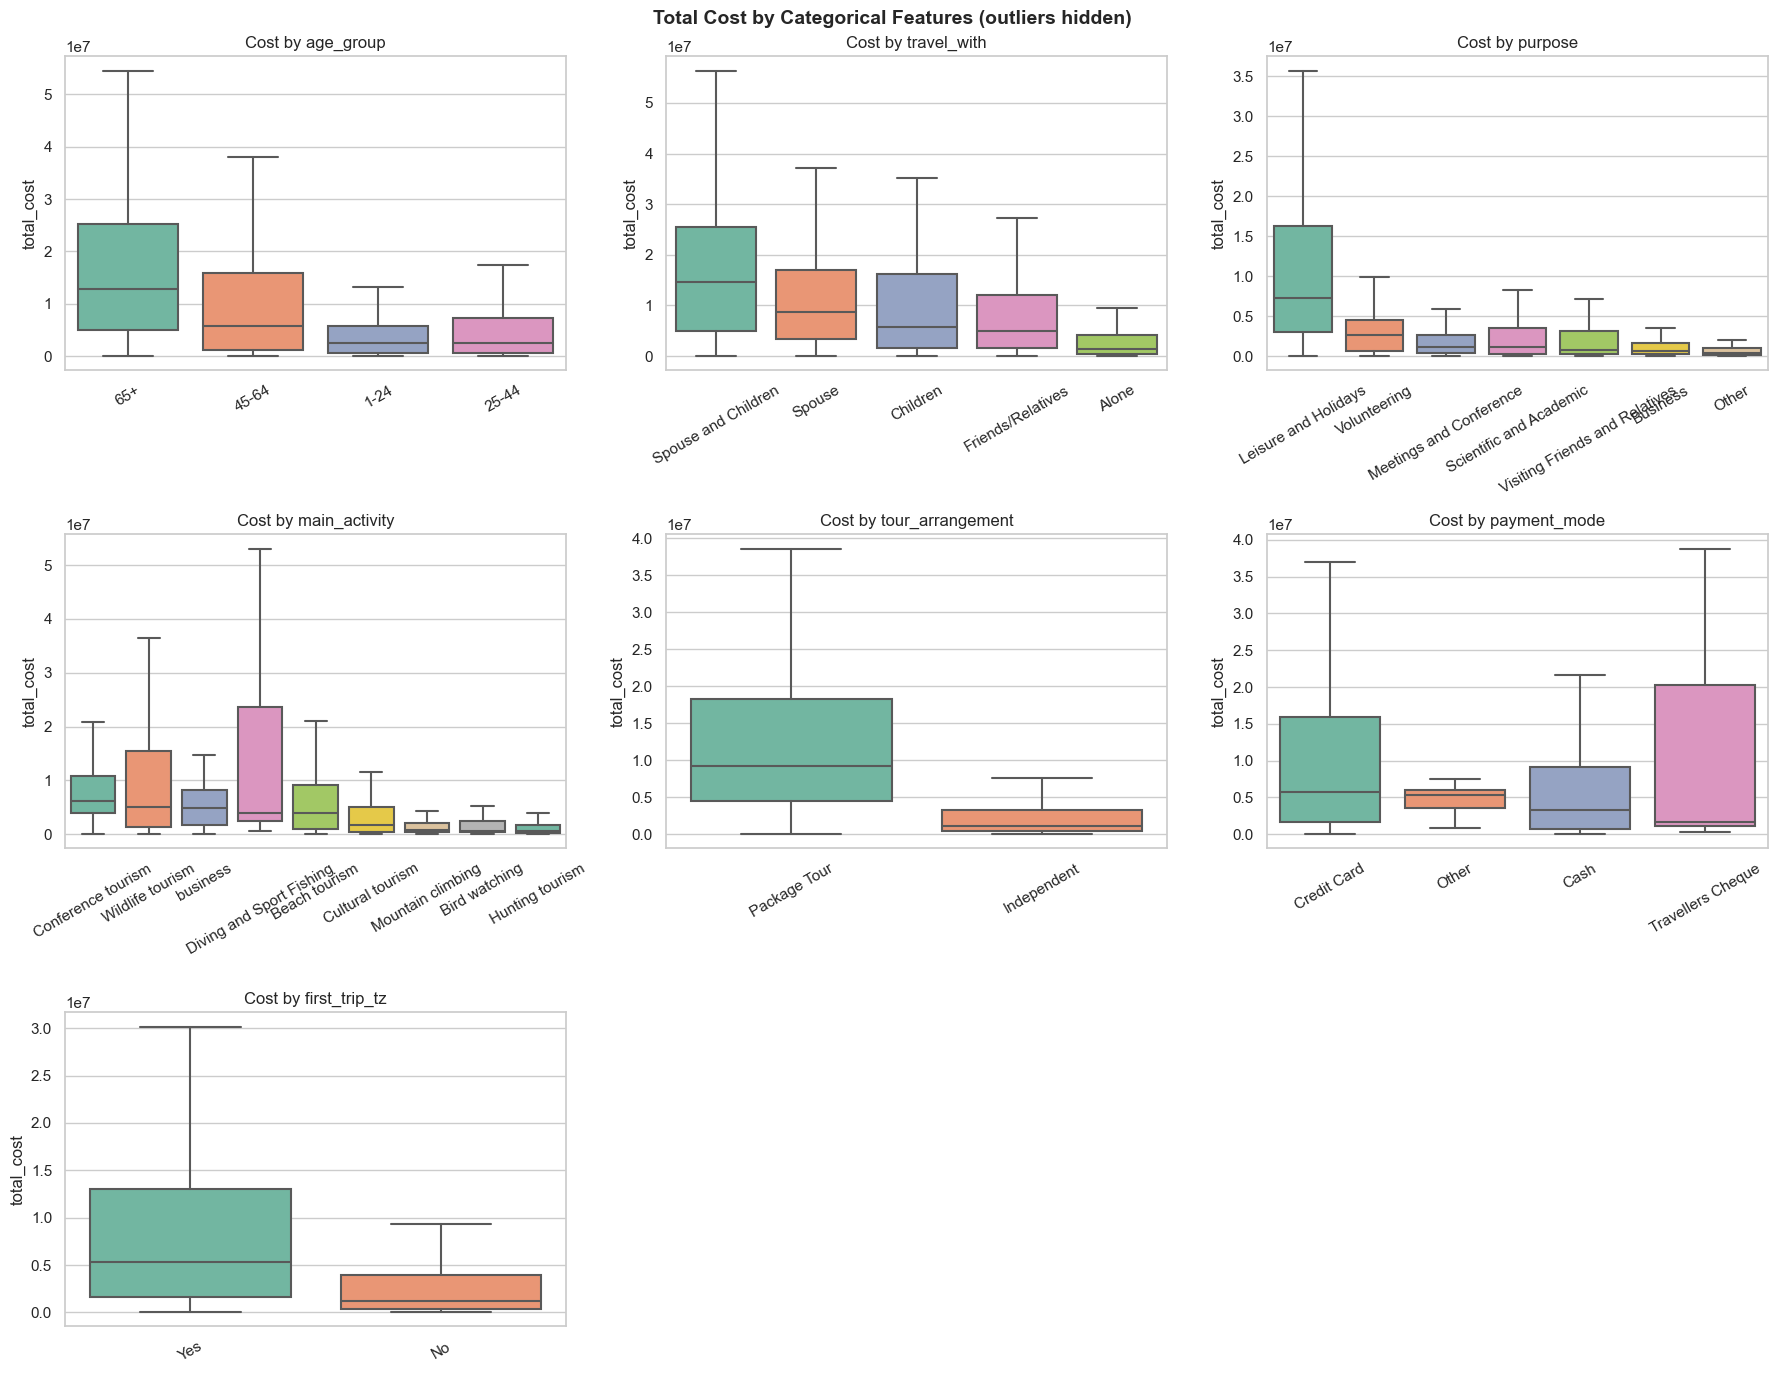

In [18]:
# ── 2.4 Categorical features vs. Total Cost ──────────────────────────────────
cat_cols = ['age_group', 'travel_with', 'purpose', 'main_activity',
            'tour_arrangement', 'payment_mode', 'first_trip_tz']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = train.groupby(col)['total_cost'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='total_cost', order=order, ax=axes[i],
                palette='Set2', showfliers=False)
    axes[i].set_title(f'Cost by {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Total Cost by Categorical Features (outliers hidden)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

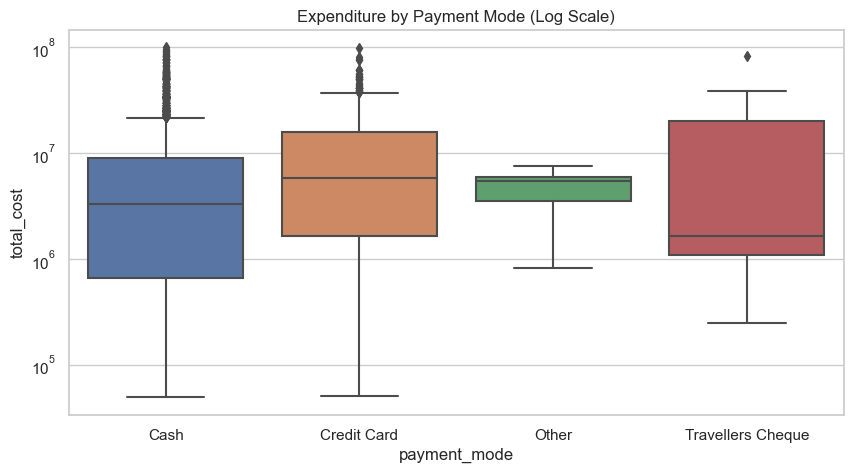

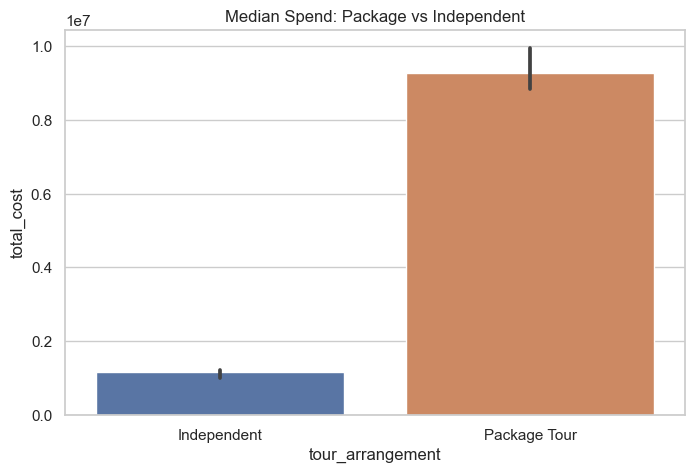

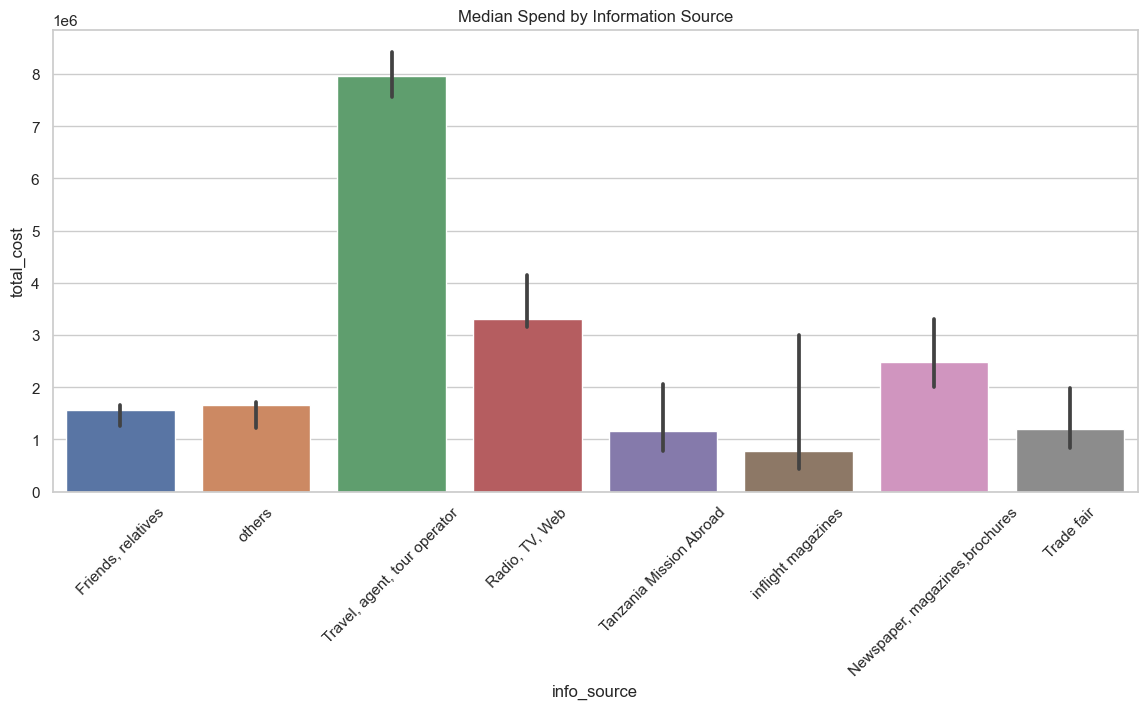

In [ ]:
# 1. Payment Mode vs Cost
# Checking if Credit Card users spend more than Cash users
plt.figure(figsize=(10, 5))
sns.boxplot(data=train, x='payment_mode', y='total_cost')
plt.yscale('log')
plt.title("Expenditure by Payment Mode (Log Scale)")
plt.show()

# 2. Tour Arrangement vs Cost
# Comparing Package vs Independent travelers
plt.figure(figsize=(8, 5))
sns.barplot(data=train, x='tour_arrangement', y='total_cost', estimator=np.median)
plt.title("Median Spend: Package vs Independent")
plt.show()

# 3. Information Source vs Cost
# Which marketing channel attracts high-spenders?
plt.figure(figsize=(14, 6))
sns.barplot(data=train, x='info_source', y='total_cost', estimator=np.median)
plt.xticks(rotation=45)
plt.title("Median Spend by Information Source")
plt.show()

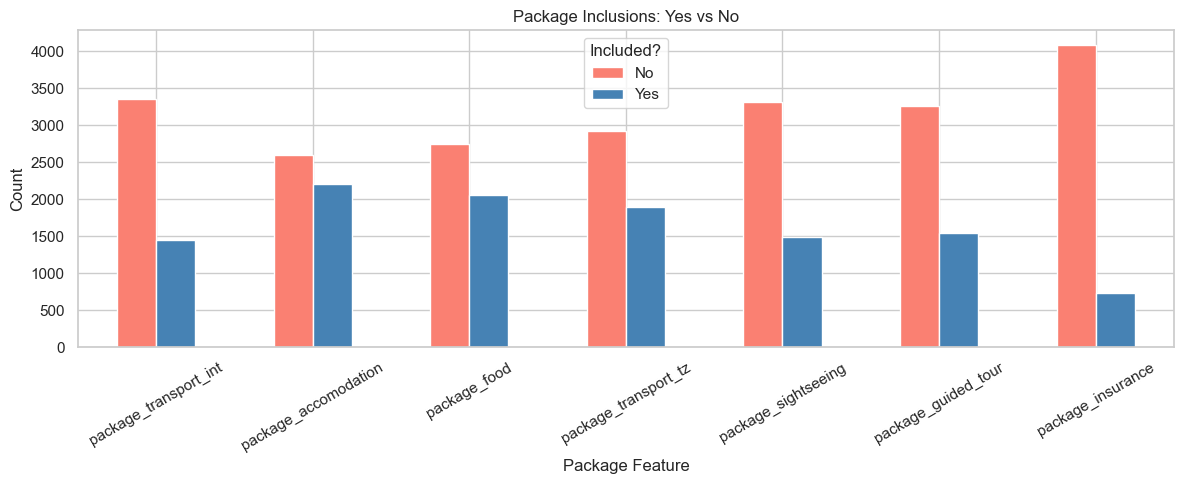

In [22]:
# ── 2.6 Package inclusions ───────────────────────────────────────────────────
package_cols = ['package_transport_int', 'package_accomodation', 'package_food',
                'package_transport_tz', 'package_sightseeing',
                'package_guided_tour', 'package_insurance']

# Count Yes vs No for each package feature
package_counts = train[package_cols].apply(lambda x: x.value_counts()).T.fillna(0)

package_counts.plot(kind='bar', figsize=(12, 5), color=['salmon', 'steelblue'])
plt.title('Package Inclusions: Yes vs No')
plt.xlabel('Package Feature')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Included?')
plt.tight_layout()
plt.show()

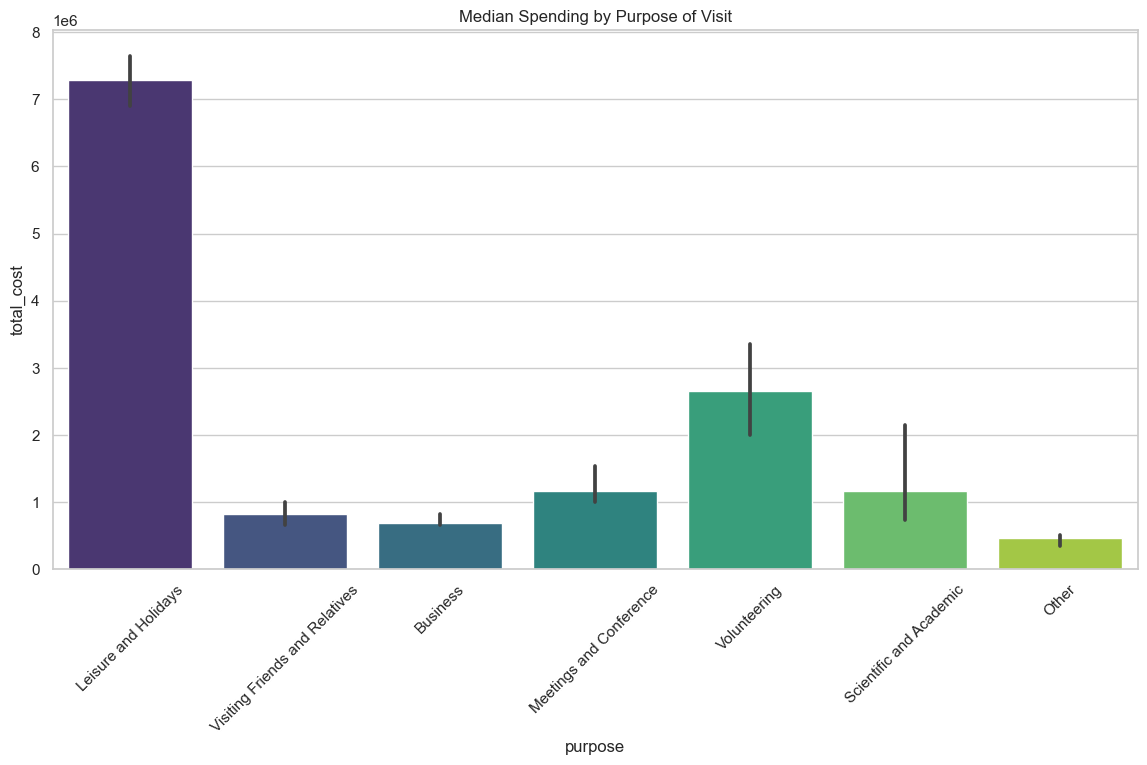

In [23]:
#### The Business Case

# Analyze relationship between categorical features and target
# We use median because of the spending outliers (whales)
plt.figure(figsize=(14, 7))
sns.barplot(data=train, x='purpose', y='total_cost', estimator=np.median, palette='viridis')
plt.title('Median Spending by Purpose of Visit')
plt.xticks(rotation=45)
plt.show()

---

End of EDA

---

#### Data Cleaning

1. Imputation

In [25]:
# 3. Data Cleaning
# Define a list of dataframes to apply changes to both at once
dfs = [train, test]

for df in dfs:
    # Handle travel_with (categorical)
    df['travel_with'] = df['travel_with'].fillna('Alone')
    
    # Handle total_female and total_male (numerical)
    # We assume NaN means zero people in that category
    df['total_female'] = df['total_female'].fillna(0)
    df['total_male'] = df['total_male'].fillna(0)
    
    # Handle most_impressing (categorical)
    df['most_impressing'] = df['most_impressing'].fillna('No Comment')

print("Missing values in Train after cleaning:")
print(train.isnull().sum()[train.isnull().sum() > 0])
print("\nMissing values in Test after cleaning:")
print(test.isnull().sum()[test.isnull().sum() > 0])

Missing values in Train after cleaning:
Series([], dtype: int64)

Missing values in Test after cleaning:
Series([], dtype: int64)


2. Datatypes: Converting group members to integers, cause it`s not possible to have 0,5. You´re female or male

In [ ]:
# Check for records with 0 total nights - these might be errors
zero_night_stays = train[(train['night_mainland'] == 0) & (train['night_zanzibar'] == 0)]
print(f"Number of records with 0 total nights: {len(zero_night_stays)}")

train['total_female'] = train['total_female'].astype(int)
train['total_male'] = train['total_male'].astype(int)
test['total_female'] = test['total_female'].astype(int)
test['total_male'] = test['total_male'].astype(int)

print("Data types converted successfully.")

Number of records with 0 total nights: 11
Data types converted successfully.


As you can see, there are also just Day-Tourist without overnight.

3. Fixing Typos

In [27]:
# 3.1 Advanced Cleaning - Fixing specific typos
for df in [train, test]:
    # Fix Switzerland typo
    df['country'] = df['country'].replace('SWIZERLAND', 'SWITZERLAND')
    
    # Fix Excel auto-date error in age_group (e.g., '24-Jan' should be '1-24')
    df['age_group'] = df['age_group'].replace('24-Jan', '1-24')

print("Unique age groups after fix:", train['age_group'].unique())
print("Check Switzerland:", 'SWIZERLAND' in train['country'].unique())

Unique age groups after fix: ['45-64' '25-44' '1-24' '65+']
Check Switzerland: False


In [28]:
# 3.2 Mapping Yes/No to 1/0
# Identifying columns that start with 'package_' plus 'first_trip_tz'
binary_cols = [col for col in train.columns if col.startswith('package_')] + ['first_trip_tz']

for df in [train, test]:
    for col in binary_cols:
        df[col] = df[col].map({'Yes': 1, 'No': 0})

print(f"Mapped {len(binary_cols)} columns to binary integers.")
train[binary_cols].head()

Mapped 8 columns to binary integers.


,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,first_trip_tz
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0
3,0,1,1,1,1,1,0,1
4,0,0,0,0,0,0,0,1


4. Deciding what to keep, not to keep or transform

In [ ]:
# 4 Logical Consistency - Ensuring there is at least 1 person per trip
for df in [train, test]:
    # Calculate total people
    df['total_people'] = df['total_female'] + df['total_male']
    
    # Check for trips with 0 people
    zero_people = df[df['total_people'] == 0]
    if len(zero_people) > 0:
        print(f"Fixing {len(zero_people)} records with 0 travelers.")
        # If both are 0, we assume at least 1 male (the traveler)
        df.loc[df['total_people'] == 0, 'total_male'] = 1
        # Recalculate
        df['total_people'] = df['total_female'] + df['total_male']

print("Sanity check passed: Total people is always >= 1.")

Fixing 17 records with 0 travelers.
Fixing 2 records with 0 travelers.
Sanity check passed: Total people is always >= 1.


In [ ]:
# 4.1 Feature Refining - Country Grouping
# Countries with very few visitors can lead to overfitting.
threshold = 10
country_counts = train['country'].value_counts()
rare_countries = country_counts[country_counts < threshold].index

for df in [train, test]:
    df['country'] = df['country'].apply(lambda x: 'Other' if x in rare_countries else x)

print(f"Number of unique countries reduced from {len(country_counts)} to {train['country'].nunique()}.")

Number of unique countries reduced from 105 to 42.


If a country appears only once and that single tourist spent an enormous amount of money, the model would incorrectly conclude: "Everyone from that country is extremely wealthy." (overfitting). By grouping the data, the model becomes more stable and learns more general patterns.

In [ ]:
# 4.2 Handling extreme outliers in stay duration
# Some tourists might stay for months, which is rare.
# We cap nights at 45 (or use a percentile like 95%)
max_nights = 45

for df in [train, test]:
    df['night_mainland'] = df['night_mainland'].clip(upper=max_nights)
    df['night_zanzibar'] = df['night_zanzibar'].clip(upper=max_nights)

print(f"Capped mainland and zanzibar nights at {max_nights} to reduce outlier influence.")

Capped mainland and zanzibar nights at 45 to reduce outlier influence.


Extreme outliers (people who stay for months) can significantly skew the model’s mathematical calculations (such as the MAE error). Since 95% of the tourists stay for less than 45 days, we protect the model from focusing too much on these rare extreme cases.

In [ ]:
# 4.3 Removing non-predictive columns
# We drop ID as it is unique to every row. 
# We drop 'most_impressing' because it is unstructured text data.

cols_to_drop = ['ID', 'most_impressing']

# We keep the IDs of the test set for the final submission file later
test_ids = test['ID']

train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

print(f"Columns remaining: {len(train.columns)}")
print(f"Dropped: {cols_to_drop}")

Columns remaining: 22
Dropped: ['ID', 'most_impressing']


In [ ]:
# 4.4 Checking for zero-cost errors in training data
zero_cost = train[train['total_cost'] <= 0]

if len(zero_cost) > 0:
    print(f"Warning: Found {len(zero_cost)} records with zero cost. Removing them.")
    train = train[train['total_cost'] > 0]
else:
    print("Sanity Check Passed: No zero-cost records found.")

# Quick look at the cleaned data
train.head()

Sanity Check Passed: No zero-cost records found.


,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,total_cost,total_people
0,SWITZERLAND,45-64,Friends/Relatives,1,1,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,0,0,0,0,0,0,0,13.0,0.0,Cash,0,674602.5,2
1,UNITED KINGDOM,25-44,Alone,1,0,Leisure and Holidays,Cultural tourism,others,Independent,0,0,0,0,0,0,0,14.0,7.0,Cash,1,3214906.5,1
2,UNITED KINGDOM,25-44,Alone,0,1,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,0,0,0,0,0,0,0,1.0,31.0,Cash,0,3315000.0,1
3,UNITED KINGDOM,25-44,Spouse,1,1,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,0,1,1,1,1,1,0,11.0,0.0,Cash,1,7790250.0,2
4,CHINA,1-24,Alone,1,0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,0,0,0,0,0,0,0,7.0,4.0,Cash,1,1657500.0,1


We dropped "ID and "tour_0", because we don`t need it and it causes white noise for the model AND we sorted out total_costs <1000TZS, even if the tourist stayed for more days. 

---

End of Data Cleaning

---

#### Train Test Split